# Лабораторная работа №2

In [384]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor, Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error,r2_score,  mean_absolute_percentage_error
import numpy as np
from scipy.stats import uniform, loguniform
from metrics import mse, rmse, mae, r_2, mape
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

In [385]:
data = pd.read_csv("data_sets/air_only_std.csv")
data.drop("Unnamed: 0", axis=1, inplace=True)
data

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,year,day,hour,month,day_of_week
0,0.562105,1.368038,0.366654,0.511072,-0.247753,0.216354,0.743050,0.763392,-0.568920,-0.012144,-0.700176,-0.535006,-0.664877,0.956395,3,3
1,0.065233,1.031941,-0.006262,0.144295,-0.624797,-0.344638,0.341011,-0.045798,-0.603599,-0.082444,-0.782006,-0.535006,-0.664877,1.099965,3,3
2,0.230857,1.575628,-0.065929,0.079806,-0.457222,0.243068,0.328920,0.233045,-0.765434,0.286630,-0.719430,-0.535006,-0.664877,1.243535,3,3
3,0.230857,1.447120,-0.036096,0.116081,-0.211844,0.456780,0.416582,0.585698,-0.869471,0.638129,-0.626959,-0.535006,-0.664877,1.387105,3,3
4,-0.266016,0.933089,-0.438846,-0.335338,-0.457222,0.296496,0.132434,0.331460,-0.846352,0.614696,-0.621639,-0.535006,-0.664877,1.530675,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8870,0.976165,1.140679,0.605321,0.732751,1.583605,2.273328,-0.218216,2.023650,0.390533,-1.160376,-0.702709,1.869136,-1.341314,-0.192165,4,1
8871,0.396481,0.394346,0.292071,0.434492,0.871410,1.979475,-0.550729,0.766126,0.667966,-1.488442,-0.816461,1.869136,-1.341314,-0.048595,4,1
8872,0.396481,0.290551,0.441238,0.579591,0.512320,1.872619,-0.620255,0.282252,0.968517,-1.804791,-0.997096,1.869136,-1.341314,0.094975,4,1
8873,0.148045,-0.396471,0.008654,0.168478,0.165200,1.365054,-1.224824,-0.598015,1.130353,-2.085991,-1.318084,1.869136,-1.341314,0.238545,4,1


Для всех моделей в качестве таргета будем использовать `CO(GT)` - количество угарного газа в воздухе.

In [386]:
y = data["CO(GT)"]

In [387]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Train Data", "Test Data"],
    metrics
])

train_and_test_comparing = pd.DataFrame(columns=columns)
train_and_test_comparing

Empty DataFrame
Columns: [(Train Data, R2), (Train Data, MSE), (Train Data, RMSE), (Train Data, MAE), (Train Data, MAPE), (Test Data, R2), (Test Data, MSE), (Test Data, RMSE), (Test Data, MAE), (Test Data, MAPE)]
Index: []

In [388]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Scikit-learn", "Кастомные функции"],
    metrics
])

sklearn_and_custom_comparing = pd.DataFrame(columns=columns)
sklearn_and_custom_comparing

Empty DataFrame
Columns: [(Scikit-learn, R2), (Scikit-learn, MSE), (Scikit-learn, RMSE), (Scikit-learn, MAE), (Scikit-learn, MAPE), (Кастомные функции, R2), (Кастомные функции, MSE), (Кастомные функции, RMSE), (Кастомные функции, MAE), (Кастомные функции, MAPE)]
Index: []

In [389]:
def get_metrics_value(y_predict, y_test):
    sklearn_metrics = [mean_squared_error, root_mean_squared_error, mean_absolute_error,r2_score,  mean_absolute_percentage_error]

    custom_metrics = [mse, rmse, mae, r_2, mape]

    sklearn_metrics_results = []
    custom_metrics_results = []

    for sklearn_metric, custom_metric in zip(sklearn_metrics, custom_metrics):
        sklearn_metrics_results.append(sklearn_metric(y_test, y_predict))
        custom_metrics_results.append(custom_metric(y_test, y_predict))

    return sklearn_metrics_results, custom_metrics_results


In [390]:
def input_into_the_tables(name_of_model,
                          predict_on_train_y, y_train,
                          predict_on_test_y, y_test,
                          sklearn_and_custom_comparing,
                          train_and_test_comparing):
    sk_learn_test_metrics, custom_test_metrics = get_metrics_value(predict_on_test_y, y_test)
    sklearn_and_custom_comparing.loc[name_of_model] = sk_learn_test_metrics + custom_test_metrics

    sk_learn_train_metrics, _ = get_metrics_value(predict_on_train_y, y_train)
    train_and_test_comparing.loc[name_of_model] = sk_learn_train_metrics + sk_learn_test_metrics


### Простая линейная регрессия

Для построения модели простой линейной регрессии в качестве предикта будем использовать признак `PT08.S1(CO)` - показатели датчика S1 об уровне CO в воздухе.

In [391]:
X = data[["PT08.S1(CO)"]]
X_train, X_test, y_train,  y_test = train_test_split(X, y, test_size=0.25)

In [392]:
model = LinearRegression()
model.fit(X_train, y_train)
predict_on_test_y = model.predict(X_test)
predict_on_train_y = model.predict(X_train)

Text(0.5, 1.0, 'Простая регрессия')

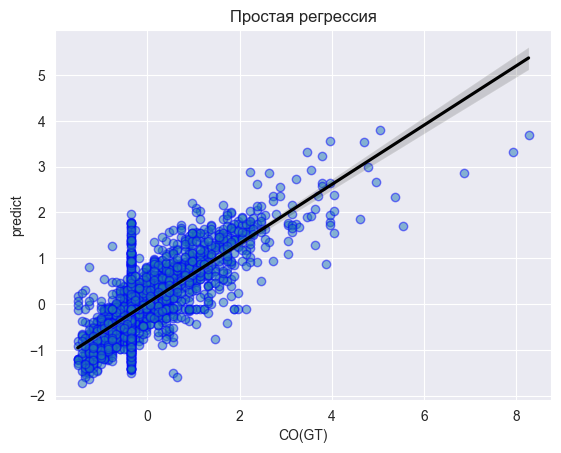

In [393]:
sns.regplot(y=predict_on_test_y, x = y_test,
            scatter_kws={"edgecolor": "blue", "alpha": 0.5},
            line_kws={"color": "black"})
plt.ylabel("predict")
plt.title("Простая регрессия")

In [394]:
input_into_the_tables("Linear regression",
                      predict_on_train_y, y_train,
                      predict_on_test_y, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

In [395]:
sklearn_and_custom_comparing.loc["Linear regression"]

Scikit-learn       R2      0.386505
                   MSE     0.621695
                   RMSE    0.431732
                   MAE     0.628740
                   MAPE    1.357531
Кастомные функции  R2      0.386505
                   MSE     0.621695
                   RMSE    0.431732
                   MAE     0.628740
                   MAPE   -0.683936
Name: Linear regression, dtype: float64

In [396]:
train_and_test_comparing.loc["Linear regression"]

Train Data  R2      0.353738
            MSE     0.594759
            RMSE    0.431231
            MAE     0.641352
            MAPE    1.308220
Test Data   R2      0.386505
            MSE     0.621695
            RMSE    0.431732
            MAE     0.628740
            MAPE    1.357531
Name: Linear regression, dtype: float64

#### Простая линейная регрессия с регуляризатором L1

Регуляризация с помощью `GridSearchCV`

In [397]:
lasso_model = Lasso()
param_grid = {'alpha':np.logspace(-10, 10)}

grid_search = GridSearchCV(
    estimator=lasso_model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

{'alpha': np.float64(0.000339322177189533)}


Регуляризация с помощью `RandomizedSearchCV`

In [398]:
randomize_search = RandomizedSearchCV(
    estimator = lasso_model,
    param_distributions = param_grid,
    scoring="neg_mean_squared_error"
)

randomize_search.fit(X_train, y_train)
print(randomize_search.best_params_)

{'alpha': np.float64(7.906043210907702e-06)}


Регуляризация с помощью Optuna

In [399]:
def lasso_objective(trial):
    alpha = trial.suggest_float('alpha', 1e-10, 1e10, log=True)
    model = Lasso(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [400]:
study = optuna.create_study(direction="minimize")
study.optimize(lasso_objective, n_trials=100)
best_params = study.best_params
best_params

[I 2026-03-04 16:59:28,461] A new study created in memory with name: no-name-df745420-2804-479c-a32a-ca9f1bae1d8b
[I 2026-03-04 16:59:28,466] Trial 0 finished with value: 1.041065194825046 and parameters: {'alpha': 62.19651107156347}. Best is trial 0 with value: 1.041065194825046.
[I 2026-03-04 16:59:28,470] Trial 1 finished with value: 0.3865048784133916 and parameters: {'alpha': 6.99250847115707e-06}. Best is trial 1 with value: 0.3865048784133916.
[I 2026-03-04 16:59:28,473] Trial 2 finished with value: 0.3864412935020501 and parameters: {'alpha': 0.0012932370953905052}. Best is trial 2 with value: 0.3864412935020501.
[I 2026-03-04 16:59:28,476] Trial 3 finished with value: 1.041065194825046 and parameters: {'alpha': 26572720.07030089}. Best is trial 2 with value: 0.3864412935020501.
[I 2026-03-04 16:59:28,479] Trial 4 finished with value: 1.041065194825046 and parameters: {'alpha': 1150.9752235130757}. Best is trial 2 with value: 0.3864412935020501.
[I 2026-03-04 16:59:28,481] Tria

{'alpha': 0.02226397217255516}

In [401]:
lasso_model = Lasso(alpha=best_params["alpha"])
lasso_model.fit(X_train, y_train)
lasso_model.predict(X_test)

sk_learn_test_metrics, custom_test_metrics

([0.003927046226218201,
  0.06266614896591462,
  0.04449099962359013,
  0.6622950728183108,
  1191525268837.5818],
 [np.float64(0.003927046226218201),
  np.float64(0.06266614896591462),
  np.float64(0.04449099962359013),
  np.float64(0.6622950728183108),
  np.float64(26457.559589609737)])

In [402]:
predict_on_train_y = lasso_model.predict(X_train)
predict_on_test_y = lasso_model.predict(X_test)

In [403]:
input_into_the_tables("Linear regression with L1",
                      predict_on_train_y, y_train,
                      predict_on_test_y, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

In [404]:
sklearn_and_custom_comparing.loc[["Linear regression with L1", "Linear regression"]]

Scikit-learn                                \
                                    R2       MSE      RMSE       MAE   
Linear regression with L1     0.385930  0.621232  0.431715  0.629292   
Linear regression             0.386505  0.621695  0.431732  0.628740   

                                    Кастомные функции                      \
                               MAPE                R2       MSE      RMSE   
Linear regression with L1  1.329990          0.385930  0.621232  0.431715   
Linear regression          1.357531          0.386505  0.621695  0.431732   

                                               
                                MAE      MAPE  
Linear regression with L1  0.629292 -0.667244  
Linear regression          0.628740 -0.683936

In [405]:
train_and_test_comparing.loc[["Linear regression with L1", "Linear regression"]]

Train Data                                          \
                                  R2       MSE      RMSE       MAE      MAPE   
Linear regression with L1   0.354246  0.595186  0.431982  0.640837  1.282872   
Linear regression           0.353738  0.594759  0.431231  0.641352  1.308220   

                          Test Data                                          
                                 R2       MSE      RMSE       MAE      MAPE  
Linear regression with L1  0.385930  0.621232  0.431715  0.629292  1.329990  
Linear regression          0.386505  0.621695  0.431732  0.628740  1.357531

Text(0.5, 1.0, 'Простая регрессия')

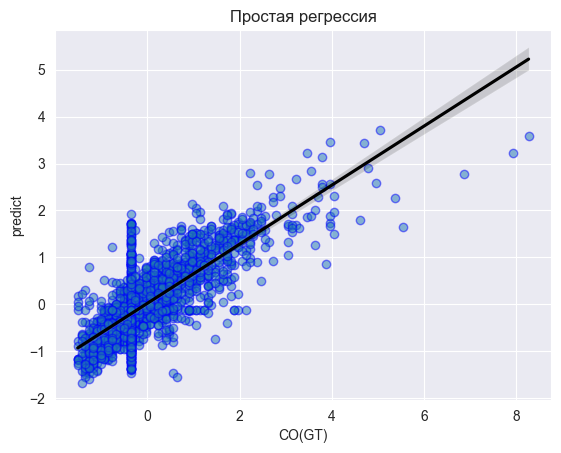

In [406]:
sns.regplot(y=predict_on_test_y, x = y_test,
            scatter_kws={"edgecolor": "blue", "alpha": 0.5},
            line_kws={"color": "black"})
plt.ylabel("predict")
plt.title("Простая регрессия")

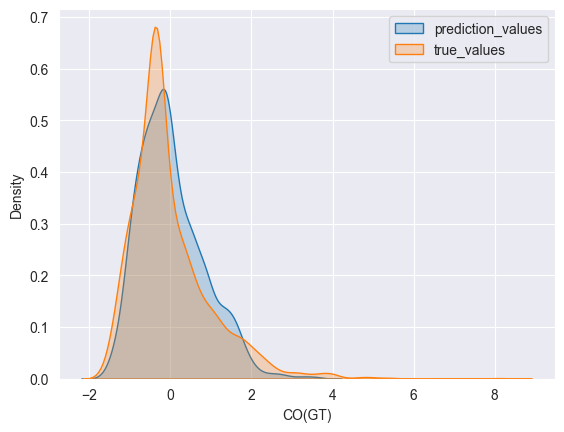

In [407]:
sns.kdeplot(predict_on_test_y, label="prediction_values", fill=True)
sns.kdeplot(y_test, label="true_values", fill=True)
plt.legend()

Значения метрик практически не изменились с применением L1 регуляризации.

#### Простая линейная регрессия с регуляризатором L2

In [408]:
randomize_search = RandomizedSearchCV(
    estimator = ridge_model,
    param_distributions = param_grid,
    scoring="neg_mean_squared_error"
)

randomize_search.fit(X_train, y_train)
print(randomize_search.best_params_)

{'alpha': np.float64(4.7148663634573897e-07)}


In [409]:
ridge_model = Ridge()
param_grid = {'alpha':np.logspace(-10, 10)}

grid_search = GridSearchCV(
    estimator=lasso_model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

{'alpha': np.float64(0.000339322177189533)}


In [410]:
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-10, 1e10, log=True)
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [411]:
study = optuna.create_study(direction="minimize")
study.optimize(lasso_objective, n_trials=100)
best_params = study.best_params
best_params

[I 2026-03-04 16:59:30,683] A new study created in memory with name: no-name-ac2276c6-8d61-4916-81e9-78078ab3f8cd
[I 2026-03-04 16:59:30,687] Trial 0 finished with value: 0.38647094129397896 and parameters: {'alpha': 0.0006841138715999778}. Best is trial 0 with value: 0.38647094129397896.
[I 2026-03-04 16:59:30,691] Trial 1 finished with value: 0.3865044314005731 and parameters: {'alpha': 1.577961260498725e-05}. Best is trial 0 with value: 0.38647094129397896.
[I 2026-03-04 16:59:30,694] Trial 2 finished with value: 1.041065194825046 and parameters: {'alpha': 1293492.7408014613}. Best is trial 0 with value: 0.38647094129397896.
[I 2026-03-04 16:59:30,697] Trial 3 finished with value: 1.041065194825046 and parameters: {'alpha': 5872399.155376493}. Best is trial 0 with value: 0.38647094129397896.
[I 2026-03-04 16:59:30,700] Trial 4 finished with value: 1.041065194825046 and parameters: {'alpha': 33.37971034830545}. Best is trial 0 with value: 0.38647094129397896.
[I 2026-03-04 16:59:30,7

{'alpha': 0.022626662035457455}

In [412]:
predict_on_train_y = grid_search.predict(X_train)
predict_on_test_y = grid_search.predict(X_test)

In [413]:
input_into_the_tables("Linear regression with L2",
                      predict_on_train_y, y_train,
                      predict_on_test_y, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

In [414]:
sklearn_and_custom_comparing.loc["Linear regression with L2"]
train_and_test_comparing.loc["Linear regression with L2"]

Train Data  R2      0.353738
            MSE     0.594759
            RMSE    0.431236
            MAE     0.641352
            MAPE    1.307828
Test Data   R2      0.386488
            MSE     0.621682
            RMSE    0.431727
            MAE     0.628756
            MAPE    1.357104
Name: Linear regression with L2, dtype: float64

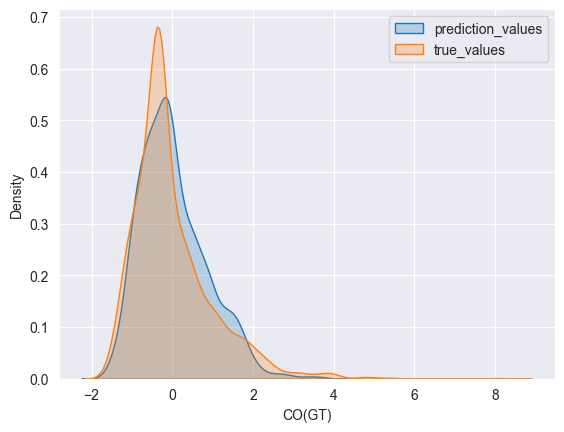

In [415]:
sns.kdeplot(predict_on_test_y, label="prediction_values", fill=True)
sns.kdeplot(y_test, label="true_values", fill=True)
plt.legend()

In [416]:
from lightgbm import LGBMRegressor
model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
model.fit(X_train, y_train)

pred = model.predict(X_test)

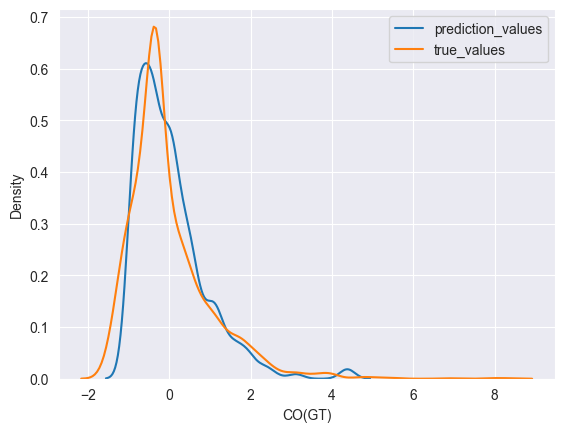